In [1]:
import pandas as pd
import numpy as np
from Bio import Phylo
from matplotlib import pyplot as plt
from tqdm import tqdm


In [24]:
## Load the tree files
tree_path = "/Users/theodorross/Library/CloudStorage/OneDrive-UiTOffice365/Documents/data/e_faecium/proc-data/microreact/combined/combined-microreact-tree.nwk"
tree = Phylo.read(tree_path, format="newick")
tree.root_at_midpoint()

## Load metadata
metadata_path = "/Users/theodorross/Library/CloudStorage/OneDrive-UiTOffice365/Documents/data/e_faecium/proc-data/microreact/expanded/expanded-microreact-labels.csv"
metadata_df = pd.read_csv(metadata_path, index_col="id")

## Load fastbaps clusters
baps_path = "/Users/theodorross/Library/CloudStorage/OneDrive-UiTOffice365/Documents/data/e_faecium/proc-data/fastbaps/combined/combined-fastbaps-clusters.csv"
df = pd.read_csv(baps_path, index_col="Isolates")
df.drop("Reference", axis=0, inplace=True)

## Add some wanted metadata
df[["Species","Clade"]] = metadata_df.loc[df.index, ["Species","Clade"]]
df.head()

,Level 1,Level 2,Level 3,Level 4,Level 5,Level 6,Species,Clade
Isolates,,,,,,,,
2016_1031_1,2,3,4,6,8,11,E. lactis,B1
2016_1063_1,2,3,4,6,8,11,E. lactis,B1
2016_1072_1,2,3,4,6,8,11,E. lactis,B1
2016_1076_1,3,5,7,13,19,29,E. faecium,A1
2016_1098,3,5,7,13,19,29,E. faecium,A1


In [68]:
def read_seqs(*filepaths):
    outseqs = []
    for fpath in filepaths:
        with open(fpath,"r") as f:
            for l in f.readlines():
                if l != "\n":
                    outseqs.append(l.rstrip("\n"))

    return outseqs

test = read_seqs("holdout-seqs/a1.txt",
                 "holdout-seqs/a2.txt",
                 "holdout-seqs/b1.txt",
                 "holdout-seqs/b2.txt")
print(len(test) / 1286)

# a2_test = read_seqs("holdout-seqs/a2.txt")
# b1_test = read_seqs("holdout-seqs/b1.txt")
# b2_test = read_seqs("holdout-seqs/b2.txt")
# print(len(a1_test), len(a2_test), len(b1_test), len(b2_test))

df.loc[test,["Clade","Species"]].value_counts()

0.1827371695178849


Clade  Species   
A1     E. faecium    73
A2     E. faecium    57
B1     E. lactis     55
B2     E. lactis     50
Name: count, dtype: int64

In [53]:
print(df["Clade"].value_counts())
print(df.loc[df["Species"]=="E. faecium",["Level 3","Clade"]].value_counts())

test3 = [7, 2,3]
df["Level 3"].value_counts(normalize=True).loc[test3].sum()
# test4 = [13,2,3,4,5]
# df["Level 4"].value_counts(normalize=True).loc[test4].sum()


Clade
A1    722
B1    269
A2    172
B2    123
Name: count, dtype: int64
Level 3  Clade
6        A1       595
5        A2       129
7        A1       127
         A2        43
Name: count, dtype: int64


np.float64(0.16718506998444788)

Level 3
6    595
4    218
7    170
5    129
1    129
3     36
2      9
Name: count, dtype: int64
Cluster  6: 595 	Clade: 606 	Clade %: 47.09
Cluster  4: 218 	Clade: 392 	Clade %: 30.46
Cluster  7: 170 	Clade: 844 	Clade %: 65.58
Cluster  5: 129 	Clade: 895 	Clade %: 69.54
Cluster  1: 129 	Clade: 129 	Clade %: 10.02
Cluster  3:  36 	Clade: 174 	Clade %: 13.52
Cluster  2:   9 	Clade:   9 	Clade %: 0.70


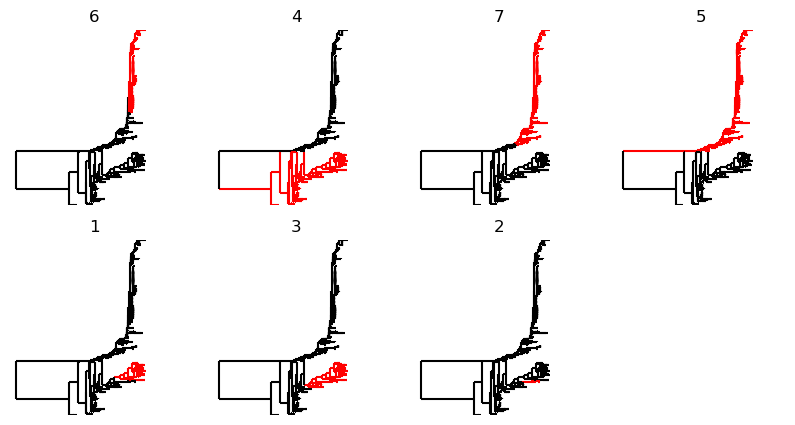

In [85]:
col = "Level 3"
vc = df[col].value_counts()
clusters = vc.index.tolist()
print(vc)
# clust = 3

colors = ["red","blue","green","orange","purple","cyan","olive"]

fig,ax = plt.subplots(2,4, figsize=(10,5))
ax = ax.ravel()

for ix,clust in enumerate(clusters):
    seqs = df[df[col]==clust].index.tolist()
    # frac = len(seqs)/tree.count_terminals()

    ancestor = tree.common_ancestor(seqs)
    # # ancestor.color = colors[ix]
    # # clade_seqs = get_clade_children(ancestor)
    clade_seqs = ancestor.get_terminals()
    print(f"Cluster {clust:2d}: {len(seqs):3d} \tClade: {len(clade_seqs):3d} \tClade %: {100*len(clade_seqs)/tree.count_terminals():0.2f}" )



    ancestor.color = "red"
    # for c in tree.get_terminals():
    #     if str(c) in seqs:
    #         c.color = colors[ix]

    Phylo.draw(tree, label_func=lambda x:None, axes=ax[ix], do_show=False)
    ax[ix].set_title(f"{clust}")
    ancestor.color = None

    # for c in tree.get_terminals():
    #     if str(c) in seqs:
    #         c.color = "black"

for a in ax: a.set_axis_off()
plt.show()